# Exploratory Data Analysis

The goal of this notebook is to:
1. Load the dataset containing images of 10 animal classes.
2. Analyze the class distribution to check for data imbalance.
3. Investigate image dimensions to determine optimal transformation parameters.

In [1]:
# Install required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

In [2]:
# Load the dataset from the Hugging Face Hub
dataset = load_dataset("dgrnd4/animals-10", split="train")

print(f"Total number of images: {len(dataset)}")
print(f"Dataset structure: {dataset.features}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

dataset.zip:   0%|          | 0.00/626M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26179 [00:00<?, ? examples/s]

Total number of images: 26179
Dataset structure: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo'])}


Original Italian classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']

Dataset translated to English:
   class_id animal_class                                         image_data
0         0          dog  {'bytes': None, 'path': 'zip://dataset/cane/OI...
1         0          dog  {'bytes': None, 'path': 'zip://dataset/cane/OI...
2         0          dog  {'bytes': None, 'path': 'zip://dataset/cane/OI...
3         0          dog  {'bytes': None, 'path': 'zip://dataset/cane/OI...
4         0          dog  {'bytes': None, 'path': 'zip://dataset/cane/OI...


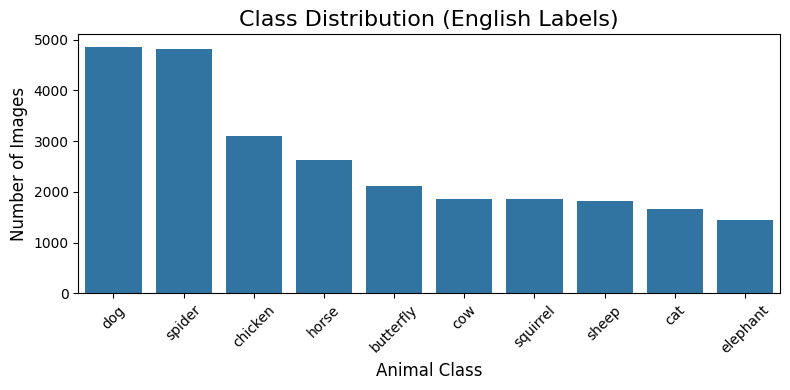

In [3]:
# The exact labels from the dataset features
original_names = dataset.features['label'].names
print(f"Original Italian classes: {original_names}")

# Map Italian to English
italian_to_english = {
    'cane': 'dog',
    'cavallo': 'horse',
    'elefante': 'elephant',
    'farfalla': 'butterfly',
    'gallina': 'chicken',
    'gatto': 'cat',
    'mucca': 'cow',
    'pecora': 'sheep',
    'ragno': 'spider',
    'scoiattolo': 'squirrel'
}

# Dataset to DataFrame
df = dataset.to_pandas()

# Map the integer 'label' to the original Italian string, then to English
df['animal_class'] = df['label'].apply(lambda x: original_names[x])
df['animal_class'] = df['animal_class'].map(italian_to_english)

# Rename columns
df = df.rename(columns={
    'image': 'image_data',
    'label': 'class_id'
})

df = df[['class_id', 'animal_class', 'image_data']]

print("\nDataset translated to English:")
print(df.head())

# 5. Visualize the new distribution with English labels
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='animal_class', order=df['animal_class'].value_counts().index)
plt.title("Class Distribution (English Labels)", fontsize=16)
plt.xlabel("Animal Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Since we discovered a significant imbalance in your chart (5,000 dogs vs. 1,500 elephants), we must address it to prevent the model from becoming biased.
#### To handle this, we will use Weighted Cross-Entropy Loss

In [ ]:
sample_size = 50
print(f"Analyzing dimensions for the first {sample_size} images...")

widths = []
heights = []

for i in range(sample_size):
    # Access the image object
    img = dataset[i]['image']

    widths.append(img.width)
    heights.append(img.height)

# Calculate averages
avg_w = int(np.mean(widths))
avg_h = int(np.mean(heights))

print(f"Analysis Complete for {sample_size} samples:")
print(f"Average Width:  {avg_w} px")
print(f"Average Height: {avg_h} px")
print(f"Min Dimensions: {min(widths)}x{min(heights)}")
print(f"Max Dimensions: {max(widths)}x{max(heights)}")

Analyzing dimensions for the first 50 images...
------------------------------
Analysis Complete for 50 samples:
Average Width:  278 px
Average Height: 241 px
Min Dimensions: 153x101
Max Dimensions: 300x300
------------------------------
